# Downloading ROIs from OMERO (3D)

Following up the notebooks about [uploading nD segmentations](rois:saving_3d) as ROIs to OMERO and the previous notebook on [restoring segmentations from uploaded ROIs](rois:loading_2d), let's look at how we can accomplish the same with nD-segmentations.

In [1]:
import ezomero
import omero_rois
import napari
import numpy as np

In [2]:
viewer = napari.Viewer(ndisplay=3)

Let's connect to our server:

In [3]:
user = 'your-user'
group = 'your-group'
host = 'your-host'
port = 4064
secure = True

conn = ezomero.connect(host=host, port=port, group=group, user=user, password=None, secure=secure)

Let's retrieve the image - again, check the OMERO browser to see the id of the uploaded image, as it will likely differ on your end.

<_ImageWrapper id=38004>
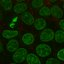

In [4]:
image_id = 38004

image_wrapper, image = ezomero.get_image(conn, image_id, dim_order='tczyx')
image_wrapper

Let's check what ROIs we find attached to this image. In our case, there are two ROIs. One for the binary mask and one for the labels image from the previous tutorial.

In [5]:
rois = image_wrapper.getROIs()
print('Number of ROIs:', len(rois))

Number of ROIs: 34


## Labels images

Let's directly try and recreate some label images from this data. We first allocate and empty label image. Note that we want to restore a 3D segmentation in this case, so

In [6]:
labels = np.zeros(image.shape, dtype=np.uint16)
labels.shape

(1, 2, 60, 256, 256)

In [7]:
for idx, roi in enumerate(rois):
    shapes = roi.copyShapes()
    for shape in shapes:
        array, metadata = omero_rois.shape_to_binary_image(shape)
        t = metadata[0]
        c = metadata[1]
        z = metadata[2]
        y = metadata[3]
        x = metadata[4]
        h = metadata[5]
        w = metadata[6]

        mask = array == 1
        labels[t, c, z, y:y+h, x:x+w][mask] = idx + 1


Let's see what we get from this:

In [8]:
image.squeeze().shape

(2, 60, 256, 256)

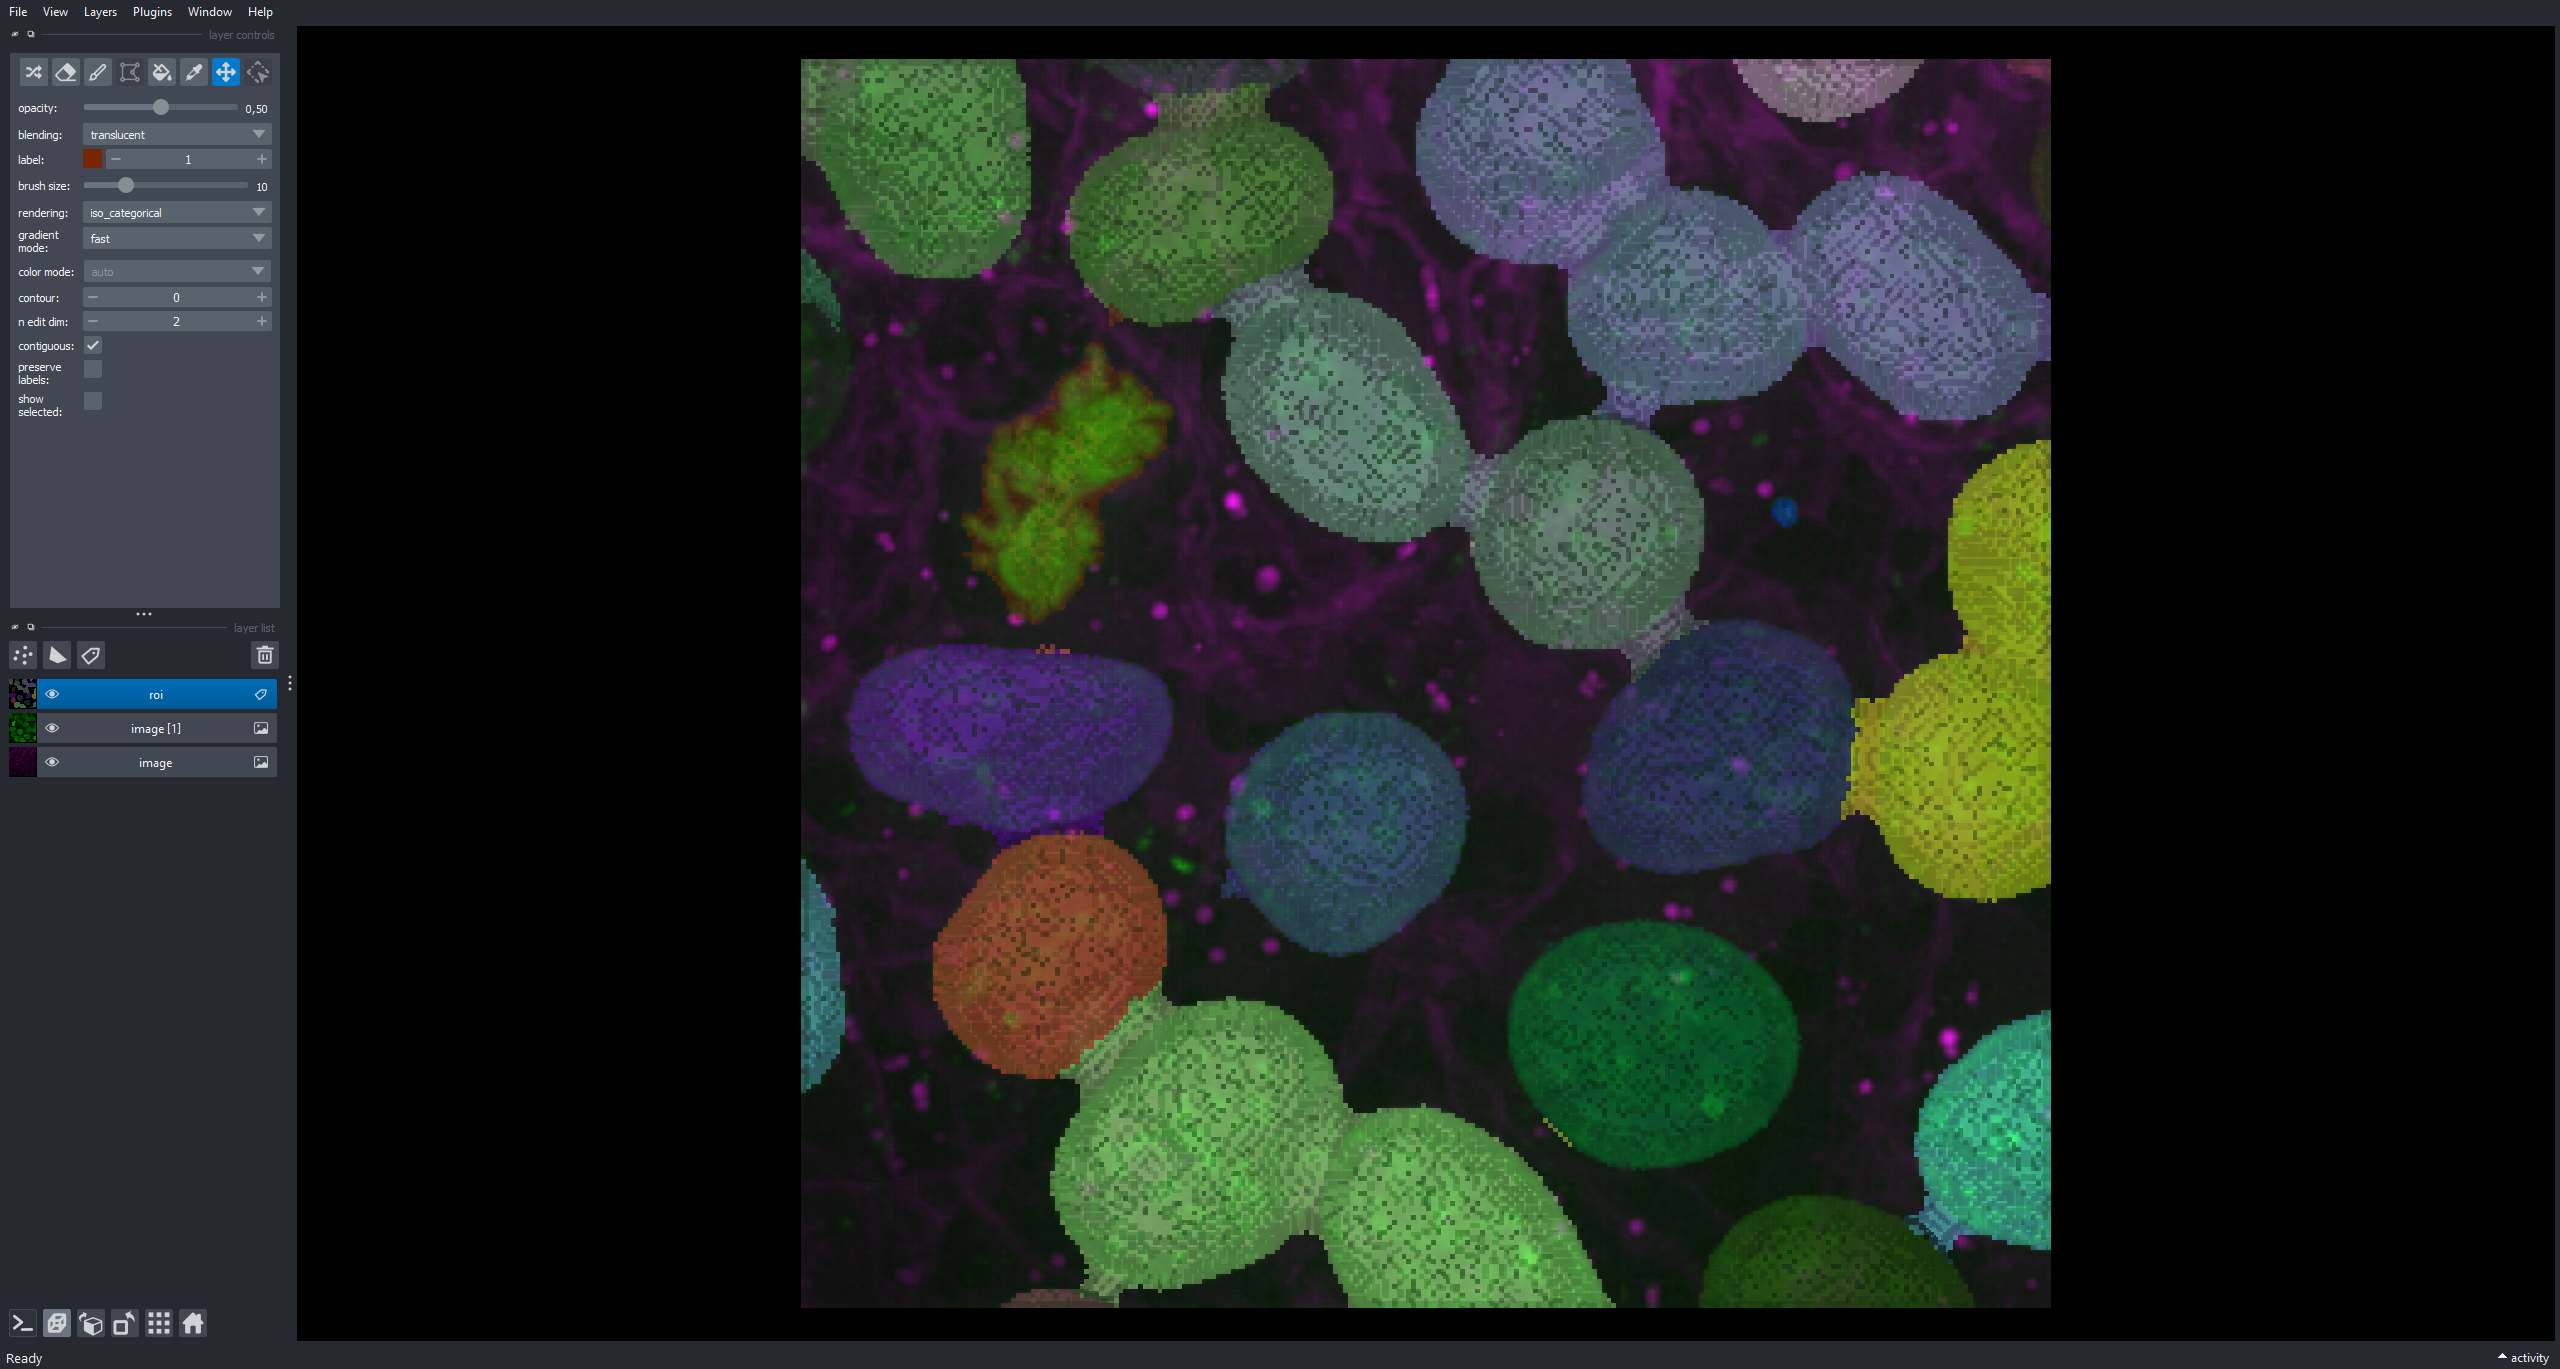

In [9]:
viewer.layers.clear()
viewer.add_image(image.squeeze(), name='image', channel_axis=0)
viewer.add_labels(labels.squeeze()[1], name='roi', opacity=0.5)
napari.utils.nbscreenshot(viewer)

There we go :)